## Performance Analyse
#### Udarbejdet af Christian Peter Hübschmann
Bachelorprojekt på DTU i "Mekanisk Design og Teknologi" om Saab T-17 i samarbejde med Flyveskolen. \
Formålet med dette script er at udregne og visualisere relevante performance-karakteristika (Climb rate, Cruise speed, Range og Endurance) for forskellige varianter af T-17.


In [1]:
# Relevante pakker
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from scipy.optimize import minimize_scalar
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.ndimage import uniform_filter1d

In [2]:
# Konstantværdier for SAAB T-17
AR = 6.58           # Aspect Ratio
S = 11.9            # m²
Lambda  = 5.0       # Leading edge sweep [grader] (forward sweep = positiv)
D = 1.88            # m (propeller diameter)
CD0 = 0.0492        # Zero-lift drag coefficient fra SAAB
e = 0.74            # Oswald effektivitetstal (typisk for propellerfly)
eps = 1/(np.pi*AR*e)  # Induced drag factor = 0.065372
P_rated_lycom_hp = 200  # hp maks. rated effekt for Lycoming motor ved SL
P_rated_delta_hp = 235  # hp maks. rated effekt for DeltaHawk motor ved SL
V_stall_max_Weight_kn = 65 # knop

# Konvertionsfaktorer
m_to_ft = 3.28084       # meter til fod
ft_to_m = 1 / m_to_ft   # fod til meter
K_to_C = -273.15        # Kelvin til Celsius
HP_to_W = 745.69987     # Hestekræfter til Watt (Aviation standard - US)
kn_to_ms = 0.514444     # Knop til m/s
ms_to_fpm = 196.8504    # m/s til fod/minut

P_rated_lycom_W = P_rated_lycom_hp * HP_to_W  # Rated effekt i Watt
P_rated_delta_W = P_rated_delta_hp * HP_to_W  # Rated effekt i Watt


def eta_p_from_J(J):
    """ Returnerer propeleffektivitet eta_p ved givet advance ratio J=V/(n·D). """
    # Digitaliserede punkter (J, eta) fra NASA-figur 4
    _J_data_NASA   = [0.2,  0.3,  0.35,  0.4,  0.45, 0.48, 0.5,  0.55, 0.6,  0.65, 0.7,  0.75, 0.8,  0.85, 0.9,  0.95, 1.0, 1.05]

    _eta_data_NASA = [0.38, 0.52, 0.58,  0.62, 0.66, 0.69, 0.71, 0.74, 0.77, 0.79, 0.81, 0.82, 0.82, 0.81, 0.78, 0.69, 0.5, 0.0]  # Bruges ikke
    _eta_data_korr = [0.31, 0.45, 0.52,  0.57, 0.61, 0.64, 0.65, 0.68, 0.71, 0.74, 0.77, 0.79, 0.80, 0.77, 0.73, 0.62, 0.42, 0.0] # Bruges i stedet

    _eta_interp = interp1d(_J_data_NASA, _eta_data_korr, kind='linear',bounds_error=False, fill_value=0.0)
    return float(_eta_interp(J))

In [3]:
# ============================================================
# 1. ATMOSFÆREMODEL  (ISA troposphere)
# ============================================================

# Konstantværdier for ISA
T0   = 288.15        # K  – ISA sea-level temperatur
p0   = 101325.0      # Pa – ISA sea-level tryk
rho0 = 1.225         # kg/m³ - ISA sea-level densitet
L    = 0.0065        # K/m – temperaturgradient (troposfæren)
g    = 9.80665       # m/s²
R    = 287.05287     # J/(kg·K)

def isa_atmosphere(h_m, delta_T_isa=0.0):
    """
    Beregner ISA-atmosfæreparametre i troposphæren (h ≤ 11 000 m).
    h_m        : geometrisk / pressure altitude [m]
    delta_T_isa: temperaturafvigelse fra ISA [°C]  (fx 0 → ISA, 25 → ISA+25)
    Returns: T [K], p [Pa], rho [kg/m³], h_da [m] (density altitude)
    """
    if h_m > 11000:
        raise ValueError("h_m skal være ≤ 11 000 m for troposfæren.")
    
    T_sl = T0 + delta_T_isa          # Effektiv SL-temperatur
    T    = T_sl - L * h_m            # Temperatur ved h_m

    T_std  = T0 - L * h_m            # Standardtemperatur (til trykberegning)
    p      = p0 * (T_std / T0) ** (g / (R * L)) # Tryk ved h_m

    rho    = p / (R * T)             # Densitet med aktuel temperatur

    # inverteret ISA-densitetsforhold til Density Altitude (DA)
    h_da = (T0 / L) * (1.0 - (rho / rho0) ** ((R*L)/(g-R*L))) 

    return T, p, rho, h_da

print("Værdi af eksponent g/(R*L): ", g / (R * L))  # Værdi af eksponent

def pa_from_da(h_da_m, delta_T_isa=0.0):
    return brentq(lambda h_p: isa_atmosphere(h_p, delta_T_isa)[3] - h_da_m, 0.0, 11000.0)

Værdi af eksponent g/(R*L):  5.255879812716677


In [4]:

# Test af atmosfæremodellen
h_test = 5000 * ft_to_m  # 5000 fod i meter

T, p, rho, h_da = isa_atmosphere(h_test) # ISA-forhold ved 5000 fod
print(f"ISA ved PA = DA = {h_test:.1f} m: T = {T:.2f} K, p = {p:.1f} Pa, rho = {rho:.4f} kg/m³, DA = {h_da:.1f} m")

T_25, p_25, rho_25, h_da_25 = isa_atmosphere(h_test, delta_T_isa=25) # ISA+25 ved 5000 fod
print(f"ISA+25 ved PA = {h_test:.1f} m: T = {T_25:.2f} K, p = {p_25:.1f} Pa, rho = {rho_25:.4f} kg/m³, DA = {h_da_25:.1f} m")
PA = pa_from_da(h_da_25, delta_T_isa=25)
print(f"PA = {PA:.1f} ud fra input af DA = {h_da_25:.1f} m (Skal gerne give {h_test:.1f} m)")

ISA ved PA = DA = 1524.0 m: T = 278.24 K, p = 84307.3 Pa, rho = 1.0555 kg/m³, DA = 1524.0 m
ISA+25 ved PA = 1524.0 m: T = 303.24 K, p = 84307.3 Pa, rho = 0.9685 kg/m³, DA = 2380.7 m
PA = 1524.0 ud fra input af DA = 2380.7 m (Skal gerne give 1524.0 m)


In [5]:
# ============================================================
# 2. MOTORMODEL
# ============================================================

def engine_power_avail_hp(P_rated_hp, h_m, delta_T_isa=0.0, turbocharged=True):
    """ Beregner tilgængelig motoreffekt [hp] som funktion af højde under ISA-forhold """

    T, p, rho, h_da = isa_atmosphere(h_m, delta_T_isa)

    if turbocharged:
        # DeltaHawk: Compound boosted turbo → fuld effekt under kritisk højde
        h_critical_m_DA = 17500 * ft_to_m   # 17.500 ft kritisk højde jf. DeltaHawk
        h_critical_m_PA = pa_from_da(h_critical_m_DA, delta_T_isa) # Find tilsvarende PA for kritisk DA
        rho_crit_PA = isa_atmosphere(h_critical_m_PA, delta_T_isa)[2] # Find kritisk densitet ved PA

        if h_da <= h_critical_m_PA:
            P_avail = P_rated_hp   # Under kritisk højde: fuld effekt
            sigma = 1.0
        else:
            if h_da >= 11000:
                rho_PA = isa_atmosphere(11000, delta_T_isa)[2] # Over 11.000 m: brug densitet ved 11.000 m (troposfæreskift)
            else:
                rho_PA = isa_atmosphere(h_da, delta_T_isa)[2] # Find densitet svarende til input DA
            sigma = rho_PA / rho_crit_PA
            P_avail = P_rated_hp * sigma # Over kritisk højde: lineær aftagning med sigma

    else:
        # Lycoming: naturlig aspiration → simpel sigma-skalering
        sigma = rho / rho0
        P_avail = P_rated_hp * sigma

    return P_avail, sigma

In [6]:
# Test af motormodel
h_test = 5500 * ft_to_m  # 5500 fod i meter
P_avail_lycom, sigma_lycom = engine_power_avail_hp(P_rated_lycom_hp, h_test, turbocharged=False) # ISA-forhold ved 5500 fod Lycoming (naturlig aspiration)
P_avail_delta, sigma_delta = engine_power_avail_hp(P_rated_delta_hp, h_test, turbocharged=True) # ISA-forhold ved 5500 fod DeltaHawk (turbocharged)
print(f"Lycoming ved {h_test:.1f} m / {h_test/ft_to_m:.1f} ft: P_avail = {P_avail_lycom:.1f} hp, sigma = {sigma_lycom:.4f}")
print(f"DeltaHawk ved {h_test:.1f} m / {h_test/ft_to_m:.1f} ft: P_avail = {P_avail_delta:.1f} hp, sigma = {sigma_delta:.4f}")
engine_power_avail_hp(P_rated_delta_hp, h_test, 25.0, turbocharged=True)

Lycoming ved 1676.4 m / 5500.0 ft: P_avail = 169.7 hp, sigma = 0.8487
DeltaHawk ved 1676.4 m / 5500.0 ft: P_avail = 235.0 hp, sigma = 1.0000


(235, 1.0)

In [7]:
# ============================================================
# 3. AERODYNAMIK  (parabolic drag polar)
# ============================================================

def CD_drag_polar(CL):
    """CD = CD0 + CL² / (π·e·AR) = CD0 + eps·CL²"""
    return CD0 + eps * CL**2

def CL_coef(W_N, V_ms, rho, gamma=0.0):
    """Beregner CL i level cruise og climb afhængig af gamma."""
    return (2 * W_N * np.cos(gamma)) / (rho * V_ms**2 * S)

def drag_at_speed(CL, V_ms, rho):
    """Beregner drag [N] ved given TAS og vægt."""
    q  = 0.5 * rho * V_ms**2
    CD = CD_drag_polar(CL)
    return CD * q * S

In [8]:
# Test af drag model 
m_test = 1000  # kg
W_N_test = m_test * g  # N
V_ms_climb = 79 * kn_to_ms  # 79 knop i m/s
V_ms_cruise = 119 * kn_to_ms  # 119 knop i m/s

# SL best climb ved 1000 kg og 79 knop
gamma = np.radians(5)  # Antaget climb angle på 5 grader
CL = CL_coef(W_N_test, V_ms_climb, rho0, gamma)  # CL i SL climb ved 79 knop
Drag = drag_at_speed(CL, V_ms_climb, rho0)
print(f"CL ved SL climb 79 knop ved SL: {CL:.4f}, med drag på {Drag:.2f} N")

# Cruise ved 1000 kg og 119 knop
rho = isa_atmosphere(5000*ft_to_m)[2]  # Densitet ved 5000ft
CL = CL_coef(W_N_test, V_ms_cruise, rho)  # CL i cruise ved 119 knop
Drag = drag_at_speed(CL, V_ms_cruise, rho)
print(f"CL ved cruise 119 knop i 5000ft: {CL:.4f}, med drag på {Drag:.2f} N")

CL ved SL climb 79 knop ved SL: 0.8115, med drag på 1110.56 N
CL ved cruise 119 knop i 5000ft: 0.4166, med drag på 1425.15 N


In [9]:
# ============================================================
# 4. CLIMB RATE
# ============================================================

def eta_p_at_speed(V_ms, n_rps, D_prop=D):
    """Beregner eta_p fra advance ratio J = V/(n·D)."""
    J = V_ms / (n_rps * D_prop)
    return eta_p_from_J(J)


def rate_of_climb(V_ms, m_kg, P_hp, h_m, n_revs, gamma, deltaT_isa=0.0, turbo=False):
    """ R/C som funktion af V [m/s] """
    eta_p_climb = eta_p_at_speed(V_ms, n_revs)
    W_N = m_kg * g
    P_W = engine_power_avail_hp(P_hp, h_m, deltaT_isa, turbocharged=turbo)[0] * HP_to_W * eta_p_climb 
    rho = isa_atmosphere(h_m, deltaT_isa)[2]
    term1 =  P_W / W_N
    term2 = (CD0 * rho * V_ms**3) / (2 * (W_N/S))
    term3 = (2 * eps * (W_N/S) * np.cos(gamma)**2) / (rho * V_ms)
    return term1 - term2 - term3


def SEP_formula(V_ms, m_kg, P_rated_hp, h_m, n_revs, gamma, deltaT_isa=0.0, turbo=False):
    """ Specific excess power (SEP) """
    eta_p_climb = eta_p_at_speed(V_ms, n_revs)
    W_N = m_kg * g
    rho = isa_atmosphere(h_m, deltaT_isa)[2]
    P_thrust = engine_power_avail_hp(P_rated_hp, h_m, deltaT_isa, turbocharged=turbo)[0]* HP_to_W * eta_p_climb
    P_drag = drag_at_speed(CL_coef(W_N, V_ms, rho, gamma), V_ms, rho) * V_ms
    return (P_thrust - P_drag) / W_N


def numeric_V_y(m_kg, P_hp, n_revs, h_m, deltaT_isa=0.0, turbo=False, plot=False):
    """
    Finder numerisk V_y ved at maksimere R/C som funktion af V.
    Verificerer resultatet via SEP-formlen som konsistenstjek.
    """    
    plot_V = np.linspace(35*kn_to_ms, 130*kn_to_ms, 100)
    gamma_RC = 0.0
    gamma_SEP = 0.0

    # --- R/C metode ---
    result_RC = minimize_scalar(lambda V: -rate_of_climb(V, m_kg, P_hp, h_m, n_revs, gamma_RC, deltaT_isa, turbo), bounds=(15, 75), method="bounded")
    V_y_RC = result_RC.x
    for _ in range(20):  # Iterativt gamma-loop ved V_y_RC for at sikre konsistens mellem R/C og gamma
        RC = rate_of_climb(V_y_RC, m_kg, P_hp, h_m, n_revs, gamma_RC, deltaT_isa, turbo)
        gamma_new = np.arcsin(np.clip(RC / V_y_RC, -1.0, 1.0))
        if abs(gamma_new - gamma_RC) < 1e-6:
            break
        gamma_RC = gamma_new

    # --- SEP metode ---
    result_SEP = minimize_scalar(lambda V: -float(SEP_formula(V, m_kg, P_hp, h_m, n_revs, 0.0, deltaT_isa, turbo=turbo)), bounds=(15, 75), method="bounded")
    V_y_SEP = result_SEP.x
    for _ in range(20):   # Iterativt gamma-loop ved V_y_SEP for at sikre konsistens mellem SEP og gamma
        SEP = float(SEP_formula(V_y_SEP, m_kg, P_hp, h_m, n_revs, gamma_SEP, deltaT_isa, turbo=turbo))
        gamma_new = np.arcsin(np.clip(SEP / V_y_SEP, -1.0, 1.0))
        if abs(gamma_new - gamma_SEP) < 1e-6:
            break
        gamma_SEP = gamma_new

    if plot:
        plot_RC  = [rate_of_climb(V, m_kg, P_hp, h_m, n_revs, gamma_RC, deltaT_isa) for V in plot_V]
        plot_SEP = [SEP_formula(V, m_kg, P_hp, h_m, n_revs, gamma_SEP, deltaT_isa=deltaT_isa, turbo=turbo) for V in plot_V]
        fig, ax = plt.subplots()
        ax.plot(plot_V / kn_to_ms, [rc * ms_to_fpm for rc in plot_RC],  label="R/C")
        ax.plot(plot_V / kn_to_ms, [sep * ms_to_fpm for sep in plot_SEP], label="SEP", linestyle="--")
        ax.axvline(V_y_RC  / kn_to_ms, color="C0", linestyle=":", label=f"$V_y$ R/C = {V_y_RC/kn_to_ms:.1f} kt")
        ax.axvline(V_y_SEP / kn_to_ms, color="C1", linestyle=":", label=f"$V_y$ SEP = {V_y_SEP/kn_to_ms:.1f} kt")
        ax.set_xlabel("TAS [kt]")
        ax.set_ylabel("R/C [fpm]")
        ax.set_title("R/C vs. SEP konsistenstjek")
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()

    return V_y_RC, V_y_SEP, np.degrees(gamma_RC), np.degrees(gamma_SEP)

def analytical_V_y(m_kg, rho):
    """Beregner analytisk V_y ved at sætte d(R/C)/dV = 0 og løse for V."""
    W_N = m_kg * g
    V_y_ana = np.sqrt((2 * (W_N/S) / rho) * np.sqrt(eps / (3 * CD0)))
    return V_y_ana


def flight_path_angle(V, RC):
    """Beregner flight path angle gamma i grader ved given TAS og R/C."""
    gamma_rad = np.arctan(RC / V)
    gamma_deg = np.degrees(gamma_rad)
    return gamma_deg

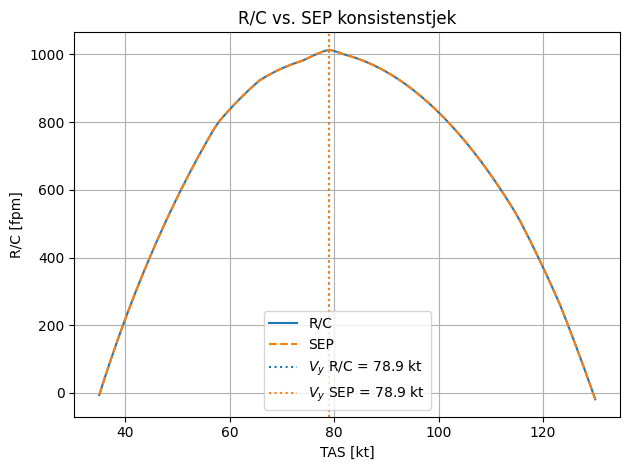

Analytisk:  V_y = 29.92 m/s  (58.2 kt)
Numerisk V_y R/C metode: 40.61 m/s  (78.9 kt)
Numerisk V_y SEP metode: 40.61 m/s  (78.9 kt)
R/C metode: gamma = 7.29 grader
SEP metode: gamma = 7.29 grader
Max R/C ved V_y R/C: 1014.4 fpm
Max SEP ved V_y SEP: 1014.4 fpm


In [10]:
# Udregninger og test
m  = 1000.0                 # kg (vægt for climb performance data)
P  = 200                    # hp (motorens rated effekt ved SL)
h = 0                  # m (højde for climb performance data)
rho = isa_atmosphere(0)[2]  # kg/m³ (ISA SL densitet)
n_climb_revs = 2700/60       # rev/s ved climb

V_y_RC, V_y_SEP, gamma_RC, gamma_SEP = numeric_V_y(m, P, n_climb_revs, h, plot=True)
V_y_ana = analytical_V_y(m, rho)
print(f"Analytisk:  V_y = {V_y_ana:.2f} m/s  ({V_y_ana*1.944:.1f} kt)")
print(f"Numerisk V_y R/C metode: {V_y_RC:.2f} m/s  ({V_y_RC*1.944:.1f} kt)")
print(f"Numerisk V_y SEP metode: {V_y_SEP:.2f} m/s  ({V_y_SEP*1.944:.1f} kt)")
print(f"R/C metode: gamma = {gamma_RC:.2f} grader")
print(f"SEP metode: gamma = {gamma_SEP:.2f} grader")

RC_max = rate_of_climb(V_y_RC, m, P, h, n_climb_revs, np.radians(gamma_RC), deltaT_isa=0.0)
SEP_max = SEP_formula(V_y_SEP, m, P, h, n_climb_revs, np.radians(gamma_SEP), deltaT_isa=0.0)
print(f"Max R/C ved V_y R/C: {RC_max*ms_to_fpm:.1f} fpm")
print(f"Max SEP ved V_y SEP: {SEP_max*ms_to_fpm:.1f} fpm")

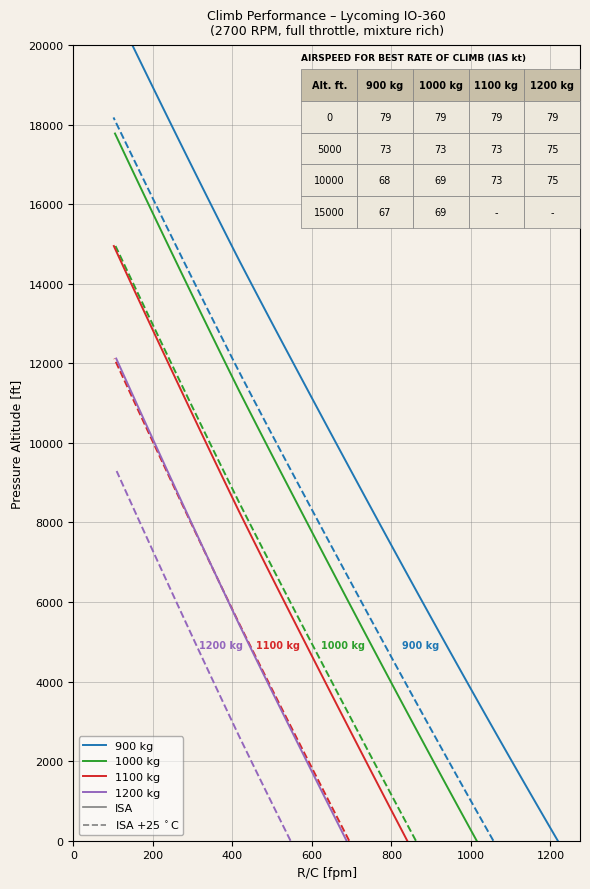

In [11]:
# ============================================================
# 5.1 CLIMB PERFORMANCE SWEEP  (0 – 20 000 ft, 4 vægte, ISA + ISA+25)
# ============================================================

masses_kg   = [900, 1000, 1100, 1200]           # kg
deltaT_list = [0.0, 25.0]                       # ISA og ISA+25
n_climb_revs = 2700 / 60                        # rev/s ved max power climb
P_climb_hp   = P_rated_lycom_hp                 # 200 hp Lycoming

h_ft_array = np.linspace(0, 20000, 100)          # pressure altitude [ft]
h_m_array  = h_ft_array * ft_to_m

# Byg resultater: RC_results[deltaT_idx][masse_idx] = array af R/C [fpm]
RC_results = {dT: {m: [] for m in masses_kg} for dT in deltaT_list} 

for dT in deltaT_list:
    for m in masses_kg:
        for h_m in h_m_array:
            # Optimér V_y og find self-konsistent gamma
            V_y, _, gamma_RC, _ = numeric_V_y(m, P_climb_hp, n_climb_revs, h_m, deltaT_isa=dT, turbo=False)
            RC_fpm = rate_of_climb(V_y, m, P_climb_hp, h_m, n_climb_revs, np.radians(gamma_RC), deltaT_isa=dT) * ms_to_fpm
            RC_results[dT][m].append(RC_fpm)

# ============================================================
# PLOT  –  Flight Manual-stil med farver
# ============================================================

fig, ax = plt.subplots(figsize=(6, 9))

fig.patch.set_facecolor("#F5F0E8")
ax.set_facecolor("#F5F0E8")

linestyles  = {0.0: "-", 25.0: "--"}
RC_MIN_FPM  = 100
colors      = {
    900:  "#1f77b4",   # blå
    1000: "#2ca02c",   # grøn
    1100: "#d62728",   # rød
    1200: "#9467bd",   # lilla
    }

for m in masses_kg:
    for dT in deltaT_list:
        rc_array = np.array(RC_results[dT][m])
        valid = rc_array >= RC_MIN_FPM
        ax.plot(rc_array[valid], h_ft_array[valid],
                color=colors[m],
                linestyle=linestyles[dT],
                linewidth=1.4)

    # Labels ved ~5000 ft
    label_idx = np.argmin(np.abs(h_ft_array - 5000))
    rc_isa   = RC_results[0.0][m][label_idx]
    rc_isa25 = RC_results[25.0][m][label_idx]

    ax.text(rc_isa - 10,   h_ft_array[label_idx], f"{m} kg", fontsize=7, va="top", 
            ha="right", color=colors[m], fontweight="bold")

# Akserne
ax.set_xlabel("R/C [fpm]", fontsize=9)
ax.set_ylabel("Pressure Altitude [ft]", fontsize=9)
ax.set_xlim(left=0)
ax.set_ylim(0, 20000)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2000))
ax.grid(True, which="major", color="gray", linewidth=0.4, alpha=0.7)
ax.tick_params(labelsize=8)

# Legende — vægte som farver + linjestil for ISA/ISA+25
legend_elements = (
    [Line2D([0], [0], color=colors[m], linewidth=1.4, label=f"{m} kg")
     for m in masses_kg]
    + [Line2D([0], [0], color="gray", linestyle="-",  linewidth=1.2, label="ISA"),
       Line2D([0], [0], color="gray", linestyle="--", linewidth=1.2, label=r"ISA $+25\,^\circ$C"),] )
ax.legend(handles=legend_elements, fontsize=8, loc="lower left", framealpha=0.6, edgecolor="gray")
ax.set_title("Climb Performance – Lycoming IO-360\n(2700 RPM, full throttle, mixture rich)",
             fontsize=9, pad=8)

# ============================================================
# INDSÆT TABEL: Airspeed for Best Rate of Climb
# ============================================================

# Beregn V_y [KIAS] ved udvalgte højder og vægte
table_altitudes_ft = [0, 5000, 10000, 15000]
table_data = []

for h_ft in table_altitudes_ft:
    h_m = h_ft * ft_to_m
    rho_h = isa_atmosphere(h_m)[2]          # densitet ved højden
    sigma = rho_h / rho0                     # densitetsforhold
    row = []
    for m in masses_kg:
        V_y_TAS = numeric_V_y(m, P_climb_hp, n_climb_revs, h_m, deltaT_isa=0.0, turbo=False)[0]
        V_y_IAS = V_y_TAS * np.sqrt(sigma)  # TAS → IAS
        RC = rate_of_climb(V_y_TAS, m, P_climb_hp, h_m, n_climb_revs, 0.0, 0.0, turbo=False)
        if RC * ms_to_fpm < RC_MIN_FPM:
            row.append("-")
        else:
            row.append(f"{V_y_IAS / kn_to_ms:.0f}")
    table_data.append(row)

# Tabel-tekst
col_labels = ["Alt. ft."] + [f"{m} kg" for m in masses_kg]
row_labels  = [str(h) for h in table_altitudes_ft]

# Byg celleindhold: første kolonne er højden, resten er V_y
cell_text = []
for i, h_ft in enumerate(table_altitudes_ft):
    cell_text.append([str(table_altitudes_ft[i])] + table_data[i])

# Placer tabellen øverst til venstre i plotområdet
the_table = ax.table(cellText=cell_text, colLabels=col_labels,cellLoc="center",
    loc="upper right", bbox=[0.45, 0.77, 0.55, 0.20],) # [x, y, bredde, højde] i axes-koordinater
the_table.set_zorder(5)
the_table.auto_set_font_size(False)
the_table.set_fontsize(7)

# Stil: header-række i mørkere baggrund
for (row, col), cell in the_table.get_celld().items():
    cell.set_edgecolor("gray")
    cell.set_linewidth(0.5)
    cell.set_facecolor("#EDE8DC")
    if row == 0:
        cell.set_facecolor("#C8BFA8")
        cell.set_text_props(fontweight="bold")

# Overskrift over tabellen
ax.text(0.45, 0.99, "AIRSPEED FOR BEST RATE OF CLIMB (IAS kt)", transform=ax.transAxes, 
        fontsize=6.5, fontweight="bold", va="top", ha="left", color="black")

plt.tight_layout()
plt.savefig("climb_performance_lycoming.pdf", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
idx_5000 = np.argmin(np.abs(h_ft_array - 5000))

for dT in [0.0, 25.0]:
    print(f"\nISA+{dT:.0f}:")
    for m in masses_kg:
        print(f"  {m} kg: {RC_results[dT][m][idx_5000]:.0f} fpm")

def time_to_climb(RC_results_dT_m, h_ft_array, h_start_ft, h_end_ft):
    """Beregner tid [min] fra h_start til h_end ved trapez-integration af dt = dh/RC."""
    mask   = (h_ft_array >= h_start_ft) & (h_ft_array <= h_end_ft)
    h_ft   = h_ft_array[mask]
    RC_ms  = np.array(RC_results_dT_m)[mask] / ms_to_fpm  # fpm → m/s
    dh_m   = np.diff(h_ft * ft_to_m)
    RC_avg = (RC_ms[:-1] + RC_ms[1:]) / 2                 # trapez-middelværdi
    return np.sum(dh_m / RC_avg) / 60.0                    # sekunder → minutter

# Eksempel: tid fra SL til 5000 ft
print()
for m in masses_kg:
    t = time_to_climb(RC_results[0.0][m], h_ft_array, 0, 5000)
    mins = int(t)
    secs = round((t - mins) * 60)
    print(f"{m} kg: {mins} min {secs} s")


ISA+0:
  900 kg: 931 fpm
  1000 kg: 742 fpm
  1100 kg: 579 fpm
  1200 kg: 436 fpm

ISA+25:
  900 kg: 776 fpm
  1000 kg: 595 fpm
  1100 kg: 437 fpm
  1200 kg: 303 fpm

900 kg: 4 min 31 s
1000 kg: 5 min 32 s
1100 kg: 6 min 52 s
1200 kg: 8 min 42 s


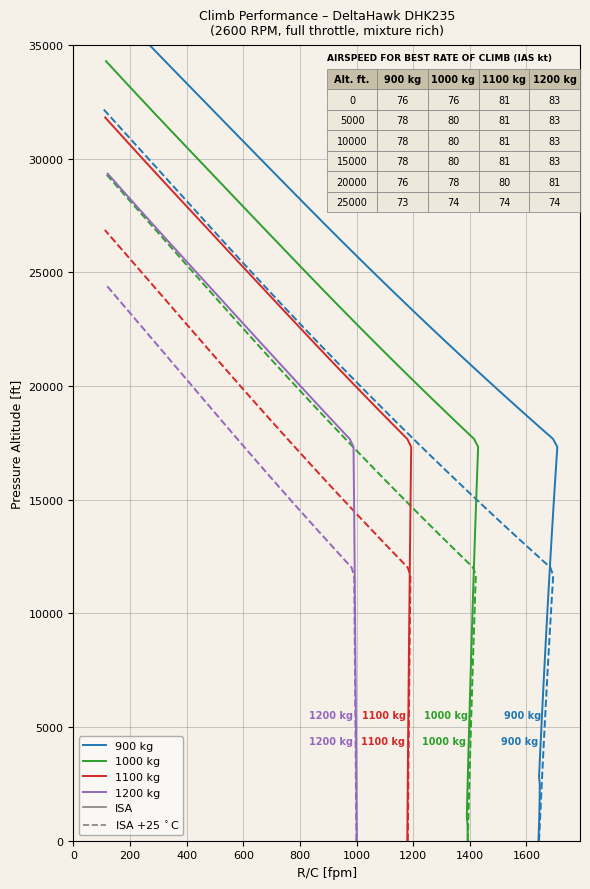

In [13]:
# ============================================================
# 5.2 CLIMB PERFORMANCE SWEEP  (0 – 20 000 ft, 4 vægte, ISA + ISA+25) - DELTAHAWK variant
# ============================================================

masses_kg    = [900, 1000, 1100, 1200]
deltaT_list  = [0.0, 25.0]
n_climb_revs = 2600 / 60                        # ← 2600 RPM (DeltaHawk max power)
P_climb_hp   = P_rated_delta_hp                 # ← 235 hp DeltaHawk

h_ft_array = np.linspace(0, 35000, 100)
h_m_array  = h_ft_array * ft_to_m

RC_results = {dT: {m: [] for m in masses_kg} for dT in deltaT_list}

for dT in deltaT_list:
    for m in masses_kg:
        for h_m in h_m_array:
            V_y, _, gamma_RC, _ = numeric_V_y(m, P_climb_hp, n_climb_revs, h_m, deltaT_isa=dT, turbo=True)   # ← turbo=True
            RC_fpm = rate_of_climb(V_y, m, P_climb_hp, h_m, n_climb_revs, np.radians(gamma_RC), deltaT_isa=dT, turbo=True) * ms_to_fpm     # ← turbo=True
            RC_results[dT][m].append(RC_fpm)

# ============================================================
# PLOT  –  Flight Manual-stil med farver
# ============================================================

fig, ax = plt.subplots(figsize=(6, 9))
fig.patch.set_facecolor("#F5F0E8")
ax.set_facecolor("#F5F0E8")

linestyles = {0.0: "-", 25.0: "--"}
RC_MIN_FPM = 100
colors = {
    900:  "#1f77b4",
    1000: "#2ca02c",
    1100: "#d62728",
    1200: "#9467bd",}

for m in masses_kg:
    for dT in deltaT_list:
        rc_array = np.array(RC_results[dT][m])
        valid = rc_array >= RC_MIN_FPM
        ax.plot(rc_array[valid], h_ft_array[valid],
                color=colors[m], linestyle=linestyles[dT], linewidth=1.4)

    label_idx = np.argmin(np.abs(h_ft_array - 5000))
    rc_isa    = RC_results[0.0][m][label_idx]
    rc_isa25  = RC_results[25.0][m][label_idx]

    ax.text(rc_isa25 - 10, h_ft_array[label_idx] + 350,
            f"{m} kg", fontsize=7, va="bottom", ha="right",
            color=colors[m], fontweight="bold")
    ax.text(rc_isa - 10,   h_ft_array[label_idx] - 350,
            f"{m} kg", fontsize=7, va="top",    ha="right",
            color=colors[m], fontweight="bold")

ax.set_xlabel("R/C [fpm]", fontsize=9)
ax.set_ylabel("Pressure Altitude [ft]", fontsize=9)
ax.set_xlim(left=0)
ax.set_ylim(0, 35000)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5000))
ax.grid(True, which="major", color="gray", linewidth=0.4, alpha=0.7)
ax.tick_params(labelsize=8)

legend_elements = (
    [Line2D([0], [0], color=colors[m], linewidth=1.4, label=f"{m} kg")
     for m in masses_kg]
    + [
        Line2D([0], [0], color="gray", linestyle="-",  linewidth=1.2, label="ISA"),
        Line2D([0], [0], color="gray", linestyle="--", linewidth=1.2,
               label=r"ISA $+25\,^\circ$C"),
    ]
)
ax.legend(handles=legend_elements, fontsize=8, loc="lower left",
          framealpha=0.6, edgecolor="gray")

ax.set_title("Climb Performance – DeltaHawk DHK235\n"   # ← opdateret titel
             "(2600 RPM, full throttle, mixture rich)",
             fontsize=9, pad=8)

# ============================================================
# INDSÆT TABEL: Airspeed for Best Rate of Climb
# ============================================================

table_altitudes_ft = [0, 5000, 10000, 15000, 20000, 25000]
table_data = []

for h_ft in table_altitudes_ft:
    h_m   = h_ft * ft_to_m
    rho_h = isa_atmosphere(h_m)[2]
    sigma = rho_h / rho0
    row   = []
    for m in masses_kg:
        V_y_TAS = numeric_V_y(m, P_climb_hp, n_climb_revs, h_m, deltaT_isa=0.0, turbo=True)[0]               # ← turbo=True
        V_y_IAS = V_y_TAS * np.sqrt(sigma)
        RC = rate_of_climb(V_y_TAS, m, P_climb_hp, h_m, n_climb_revs, 0.0, 0.0, turbo=True)                  # ← turbo=True
        if RC * ms_to_fpm < RC_MIN_FPM:
            row.append("-")
        else:
            row.append(f"{V_y_IAS / kn_to_ms:.0f}")
    table_data.append(row)

col_labels = ["Alt. ft."] + [f"{m} kg" for m in masses_kg]
cell_text  = [[str(h_ft)] + table_data[i]
              for i, h_ft in enumerate(table_altitudes_ft)]

the_table = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc="center",
                     loc="upper right", bbox=[0.5, 0.79, 0.5, 0.18])
the_table.set_zorder(5)
the_table.auto_set_font_size(False)
the_table.set_fontsize(7)

for (row, col), cell in the_table.get_celld().items():
    cell.set_edgecolor("gray")
    cell.set_linewidth(0.5)
    cell.set_zorder(5)
    cell.set_facecolor("#EDE8DC")
    if row == 0:
        cell.set_facecolor("#C8BFA8")
        cell.set_text_props(fontweight="bold")

ax.text(0.5, 0.99, "AIRSPEED FOR BEST RATE OF CLIMB (IAS kt)",
        transform=ax.transAxes,
        fontsize=6.5, fontweight="bold", va="top", ha="left")

plt.tight_layout()
plt.savefig("climb_performance_deltahawk.pdf", dpi=150, bbox_inches="tight")  # ← nyt filnavn
plt.show()

In [14]:
# Korte udregninger til sammenligning i rapport

idx_5000 = np.argmin(np.abs(h_ft_array - 5000))

for dT in [0.0, 25.0]:
    print(f"\nISA+{dT:.0f}:")
    for m in masses_kg:
        print(f"  {m} kg: {RC_results[dT][m][idx_5000]:.0f} fpm")


def time_to_climb(RC_results_dT_m, h_ft_array, h_start_ft, h_end_ft):
    """Beregner tid [min] fra h_start til h_end ved trapez-integration af dt = dh/RC."""
    mask   = (h_ft_array >= h_start_ft) & (h_ft_array <= h_end_ft)
    h_ft   = h_ft_array[mask]
    RC_ms  = np.array(RC_results_dT_m)[mask] / ms_to_fpm  # fpm → m/s
    dh_m   = np.diff(h_ft * ft_to_m)
    RC_avg = (RC_ms[:-1] + RC_ms[1:]) / 2                 # trapez-middelværdi
    return np.sum(dh_m / RC_avg) / 60.0                    # sekunder → minutter

# Eksempel: tid fra SL til 5000 ft
print()
for m in masses_kg:
    t = time_to_climb(RC_results[0.0][m], h_ft_array, 0, 5000)
    mins = int(t)
    secs = round((t - mins) * 60)
    print(f"{m} kg: {mins} min {secs} s")


ISA+0:
  900 kg: 1653 fpm
  1000 kg: 1398 fpm
  1100 kg: 1183 fpm
  1200 kg: 998 fpm

ISA+25:
  900 kg: 1664 fpm
  1000 kg: 1404 fpm
  1100 kg: 1185 fpm
  1200 kg: 996 fpm

900 kg: 3 min 0 s
1000 kg: 3 min 33 s
1100 kg: 4 min 11 s
1200 kg: 4 min 57 s


power required at 110kn, 1000kg, 5000ft =  98.81260480557675 hp
power available at 110kn, 5000ft, 200 hp, ISA =  135.25839910888615 hp



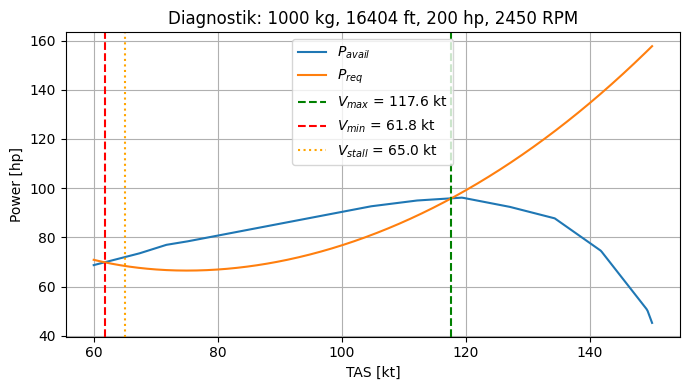

V_min ved 1000kg, 5000ft, 75% power, 2450 RPM =  61.77254722570101 kt
V_max ved 1000kg, 5000ft, 75% power, 2450 RPM =  117.64474143916817 kt

Kører cruise_speed_sweep for 75% power setting...
(65.0, 120.13675016317872, 4999.999511760391)

75% / 2450 RPM → ceiling = 9192 ft, V_max = 123.5 kt
65% / 2350 RPM → ceiling = 13788 ft, V_max = 119.2 kt
55% / 2250 RPM → ceiling = 18737 ft, V_max = 111.7 kt


In [15]:
# ============================================================
# 6. CRUISE SPEED  — generelle funktioner
# ============================================================

def power_required(V_ms, m_kg, h_m, deltaT_isa=0.0):
    """Power required for at opretholde cruise speed i W"""
    T, p, rho, h_da = isa_atmosphere(h_m, deltaT_isa)
    W_N = m_kg * g
    P_parasit = CD0 * 0.5 * rho * V_ms**3 * S
    P_induced = eps * (2 * W_N**2) / (rho * V_ms * S)
    return P_parasit + P_induced

def power_available_cruise(V_ms, h_m, P_rated_hp, n_rps, pct=100, deltaT_isa=0.0, turbo=False):
    """Power available ved given cruise speed og højde."""
    P_avail_hp     = engine_power_avail_hp(P_rated_hp, h_m, deltaT_isa, turbo)[0]
    P_requested_hp = (pct / 100.0) * P_rated_hp
    P_cruise_hp    = min(P_requested_hp, P_avail_hp)
    eta            = eta_p_at_speed(V_ms, n_rps)
    return eta * P_cruise_hp * HP_to_W

h_test = 5000 * ft_to_m  # 5000 fod i meter
m_test = 1000              # kg
V_test = 110 * kn_to_ms     # 110 kn i m/s
RPM_test = 2450    # RPM
print("power required at 110kn, 1000kg, 5000ft = ", power_required(V_test, m_test, h_test)/HP_to_W, "hp")
print("power available at 110kn, 5000ft, 200 hp, ISA = ", power_available_cruise(V_test, h_test, P_rated_lycom_hp, RPM_test/60)/HP_to_W, "hp")
print()

def find_V_cruise_bounds(m_kg, h_m, P_rated_hp, n_rps, pct=100, V_low_kn=60, V_high_kn=150, n_points=500, deltaT_isa=0.0, turbo=False, plot=False):
    """ Finder V_min og V_max [m/s].
    - Hvis to skæringer: V_min og V_max er de to krydsninger
    - Hvis én skæring:   V_min = V_stall, V_max = den fundne krydsning
    - Hvis ingen:        returner (None, None) """
    V_grid = np.linspace(V_low_kn * kn_to_ms, V_high_kn * kn_to_ms, n_points)

    P_avail_grid = np.array([power_available_cruise(V, h_m, P_rated_hp, n_rps, pct, deltaT_isa, turbo) for V in V_grid])
    P_req_grid   = np.array([power_required(V, m_kg, h_m, deltaT_isa) for V in V_grid])
    excess = P_avail_grid - P_req_grid

    sign_changes = np.where(np.diff(np.sign(excess)))[0]

    if len(sign_changes) == 0:
        return None, None  # P_avail < P_req overalt — ikke realiserbar
    
    def interpolate_crossing(idx):
        return V_grid[idx] + (V_grid[idx+1] - V_grid[idx]) * (-excess[idx] / (excess[idx+1] - excess[idx]))
    
    # Filtrer skæringer der ligger mindre end 5 kt fra hinanden
    min_separation = 5 * kn_to_ms
    filtered = [sign_changes[0]]
    for idx in sign_changes[1:]:
        V_new = interpolate_crossing(idx)
        V_prev = interpolate_crossing(filtered[-1])
        if abs(V_new - V_prev) > min_separation:
            filtered.append(idx)
    sign_changes = filtered

    if len(sign_changes) == 1:
        V_min = V_stall_max_Weight_kn * kn_to_ms
        V_max = interpolate_crossing(sign_changes[0])

    else:
        V_min = interpolate_crossing(sign_changes[0])
        V_max = interpolate_crossing(sign_changes[-1])

    if plot:
        h_ft = h_m * m_to_ft

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(V_grid / kn_to_ms, P_avail_grid / HP_to_W, label="$P_{avail}$")
        ax.plot(V_grid / kn_to_ms, P_req_grid   / HP_to_W, label="$P_{req}$")

        if V_max is not None:
            ax.axvline(V_max / kn_to_ms, color="green",  linestyle="--", label=f"$V_{{max}}$ = {V_max/kn_to_ms:.1f} kt")
        if V_min is not None:
            ax.axvline(V_min / kn_to_ms, color="red",    linestyle="--", label=f"$V_{{min}}$ = {V_min/kn_to_ms:.1f} kt")
        
        ax.axvline(V_stall_max_Weight_kn, color="orange", linestyle=":",label=f"$V_{{stall}}$ = {V_stall_max_Weight_kn:.1f} kt")

        ax.set_xlabel("TAS [kt]")
        ax.set_ylabel("Power [hp]")
        ax.set_title(f"Diagnostik: {m_kg} kg, {h_ft:.0f} ft, {P_rated_hp} hp, {n_rps*60:.0f} RPM")
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()

    return V_min, V_max

def cruise_speed_sweep(P_rated_hp, power_settings, masses_kg, h_ft_array, deltaT_isa=0.0, turbo=False):
    """ Ydre loop over alle (power setting, vægt, højde)-kombinationer.
        Returnerer dict: results[pct][m_kg] = liste af (V_min_TAS_kn, V_max_TAS_kn, h_da_ft) per højde."""
    results = {pct: {m: [] for m in masses_kg} for pct in power_settings}

    for pct, rpm in power_settings.items():
        P_requested_hp = (pct / 100.0) * P_rated_hp
        n_rps = rpm / 60.0

        for m in masses_kg:
            for h_ft in h_ft_array:
                h_m = h_ft * ft_to_m
                _, _, _, h_da_m = isa_atmosphere(h_m, deltaT_isa)
                h_da_ft = h_da_m * m_to_ft

                # Realiserbarhedstjek — stop tidligt hvis motoren ikke kan levere
                P_avail_hp_raw = engine_power_avail_hp(P_rated_hp, h_m, deltaT_isa, turbo)[0]
                if P_requested_hp > P_avail_hp_raw:
                    results[pct][m].append(None)
                    continue

                # Find V_min og V_max
                V_min_ms, V_max_ms = find_V_cruise_bounds(m, h_m, P_rated_hp, n_rps, pct, deltaT_isa=deltaT_isa, turbo=turbo)

                if V_min_ms is None:
                    results[pct][m].append(None)
                else:
                    results[pct][m].append((V_min_ms / kn_to_ms,  V_max_ms / kn_to_ms, h_da_ft))
    return results


# Test cruise_speed_sweep mod find_V_cruise_bounds direkte
power_settings = {75: 2450, 65: 2350, 55: 2250}
m_test    = 1000
h_ft_test = 5000
pct_test  = 75
rps_test  = 2450/60

print("V_min ved 1000kg, 5000ft, 75% power, 2450 RPM = ", find_V_cruise_bounds(m_test, h_ft_test, P_rated_lycom_hp, rps_test, pct=pct_test, plot=True)[0]/kn_to_ms, "kt")
print("V_max ved 1000kg, 5000ft, 75% power, 2450 RPM = ", find_V_cruise_bounds(m_test, h_ft_test, P_rated_lycom_hp, rps_test, pct=pct_test, plot=False)[1]/kn_to_ms, "kt")
print()
print("Kører cruise_speed_sweep for 75% power setting...")
sweep_results = cruise_speed_sweep(P_rated_lycom_hp, power_settings, [m_test], [h_ft_test], deltaT_isa=0.0, turbo=False)
print(sweep_results[pct_test][m_test][0])
print()


def find_ceiling_at_power(P_rated_hp, pct, rpm, m_kg, h_ft_array, deltaT_isa=0.0, turbo=False):
    h_ceil_ft = None
    V_ceil_kn = None
    n_rps = rpm / 60.0

    for h_ft in h_ft_array:
        h_m = h_ft * ft_to_m
        _, _, _, h_da_m = isa_atmosphere(h_m, deltaT_isa)

        # Realiserbarhedstjek
        P_avail_hp     = engine_power_avail_hp(P_rated_hp, h_m, deltaT_isa, turbo)[0]
        P_requested_hp = (pct / 100.0) * P_rated_hp
        if P_requested_hp > P_avail_hp:
            break

        V_min_ms, V_max_ms = find_V_cruise_bounds( m_kg, h_m, P_rated_hp, n_rps, pct=pct, V_low_kn=60, V_high_kn=150, n_points=200, deltaT_isa=deltaT_isa, turbo=turbo)

        if V_max_ms is not None:
            h_ceil_ft = h_da_m * m_to_ft
            V_ceil_kn = V_max_ms / kn_to_ms
        else:
            break

    return V_ceil_kn, h_ceil_ft

# Test find_ceiling_at_power
# Forventet: ceiling ved ~9500 ft for 75% power, 1000 kg jf. Flight Manual
for pct, rpm in power_settings.items():
    V_ceil, h_ceil = find_ceiling_at_power(P_rated_lycom_hp, pct, rpm, 1000, h_ft_array, deltaT_isa=0.0, turbo=False)
    print(f"{pct}% / {rpm} RPM → ceiling = {h_ceil:.0f} ft, V_max = {V_ceil:.1f} kt")

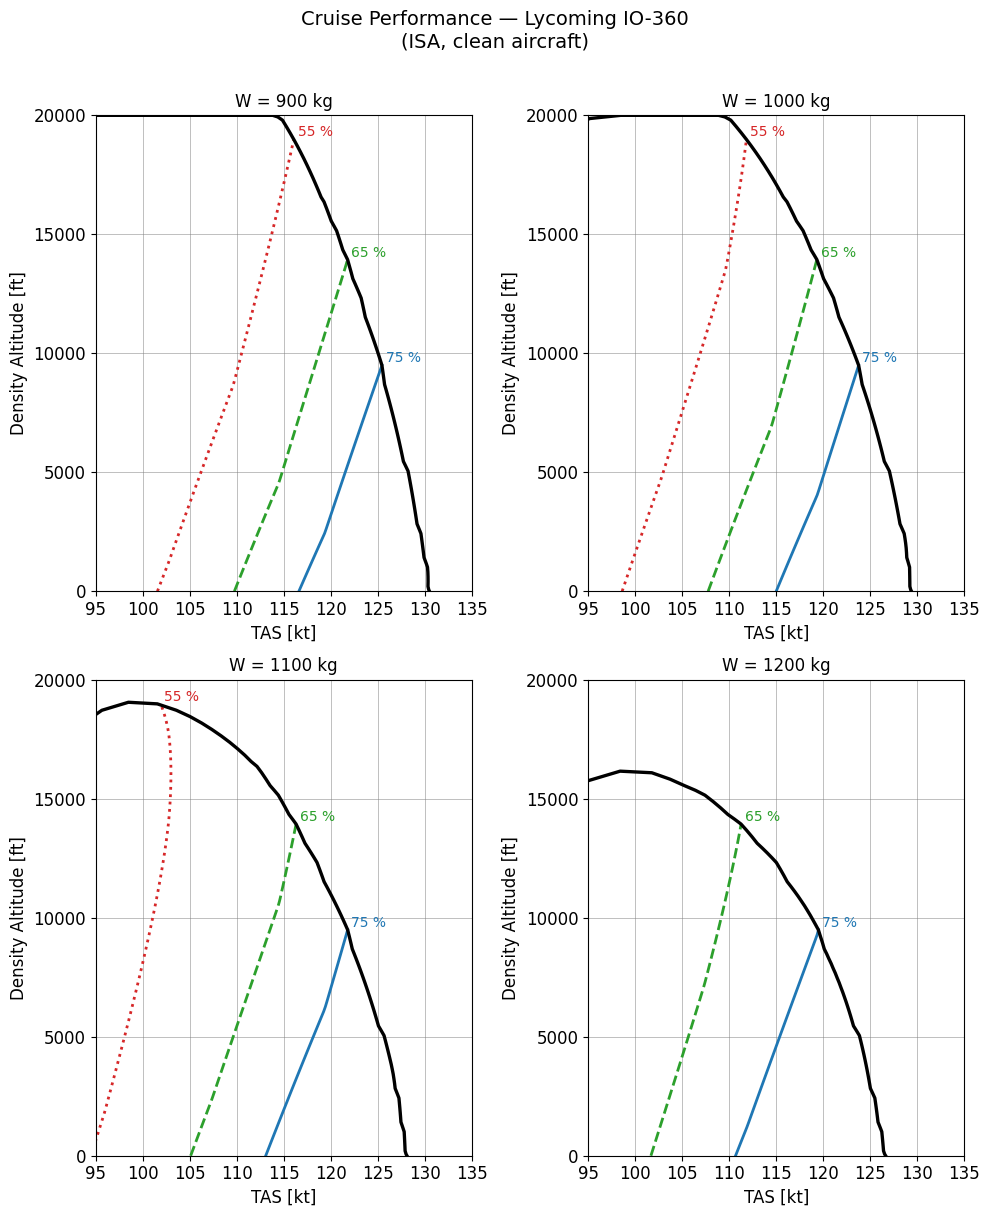

In [16]:
# ============================================================
# 7.1 CRUISE SPEED — Lycoming-specifik kørsel og plot
# ============================================================

power_settings = {75: 2450, 65: 2350, 55: 2250}
masses_kg    = [900, 1000, 1100, 1200]
h_ft_array   = np.linspace(0, 20000, 100)

cruise_results_lycom = cruise_speed_sweep(
    P_rated_hp        = P_rated_lycom_hp,
    power_settings    = power_settings,
    masses_kg         = masses_kg,
    h_ft_array        = h_ft_array,
    deltaT_isa        = 0.0,
    turbo             = False)

pct_sweep  = np.arange(40, 101, 0.5)
rpm_interp = interp1d([55, 65, 75, 100], [2250, 2350, 2450, 2700], kind='linear', fill_value='extrapolate')

linestyles = {75: "-", 65: "--", 55: ":"}
colors     = {75: "#1f77b4", 65: "#2ca02c", 55: "#d62728"}

fig, axes = plt.subplots(2, 2, figsize=(10, 12), sharey=False)
axes_flat  = [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]

for ax, m in zip(axes_flat, masses_kg):

    # ── V_max kurver ──
    for pct in power_settings.keys():
        V_max_list, h_da_list = [], []

        for val in cruise_results_lycom[pct][m]:
            if val is None:
                continue
            V_min_kn, V_max_kn, h_da_ft = val
            V_max_list.append(V_max_kn)
            h_da_list.append(h_da_ft)

        if len(h_da_list) == 0:
            continue

        ax.plot(V_max_list, h_da_list, linestyle=linestyles[pct], color=colors[pct], linewidth=2.0)
        top = np.argmax(h_da_list)
        if not (m == 1200 and pct == 55):
            ax.text(V_max_list[top] + 0.4, h_da_list[top], f"{pct} %", fontsize=10, va="bottom", color=colors[pct])

    # ── Ceiling-kurve ──
    V_ceil_list, h_ceil_list = [], []
    for pct_c in pct_sweep:
        rpm_c = float(rpm_interp(pct_c))
        V_c, h_c = find_ceiling_at_power(P_rated_lycom_hp, pct_c, rpm_c, m, h_ft_array, deltaT_isa=0.0, turbo=False)
        if V_c is not None:
            V_ceil_list.append(V_c)
            h_ceil_list.append(h_c)

    if len(V_ceil_list) > 0:
        V_ceil_smooth = uniform_filter1d(V_ceil_list, size=3)
        h_ceil_smooth = uniform_filter1d(h_ceil_list, size=3)
        ax.plot(V_ceil_smooth, h_ceil_smooth, color="black", linewidth=2.4, linestyle="-")

    ax.set_title(f"W = {m} kg", fontsize=12)
    ax.set_xlim(95, 135)
    ax.set_ylim(0, 20000)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(5000))
    ax.set_xlabel("TAS [kt]", fontsize=12)
    ax.set_ylabel("Density Altitude [ft]", fontsize=12)
    ax.grid(True, which="major", color="gray", linewidth=0.5, alpha=0.7)
    ax.tick_params(labelsize=12)

fig.suptitle("Cruise Performance — Lycoming IO-360\n(ISA, clean aircraft)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("cruise_performance_lycoming.pdf", dpi=150, bbox_inches="tight")
plt.show()

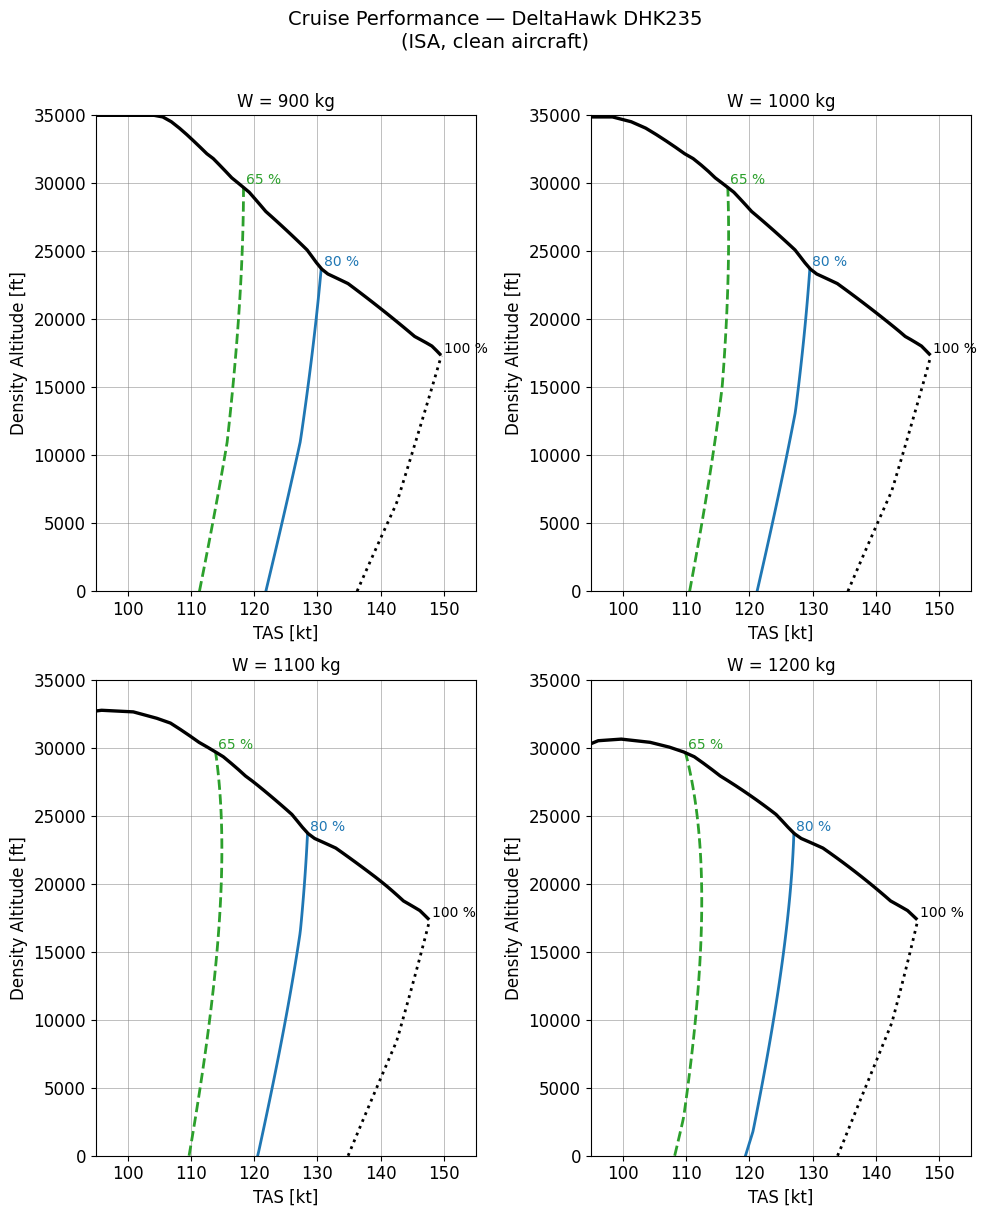

In [17]:
# ============================================================
# 7.2 CRUISE SPEED — DeltaHawk-specifik kørsel og plot
# ============================================================

power_settings = {65: 2000,80: 2200, 100: 2600}
masses_kg    = [900, 1000, 1100, 1200]
h_ft_array   = np.linspace(0, 35000, 100)

cruise_results_delta = cruise_speed_sweep(
    P_rated_hp        = P_rated_delta_hp,
    power_settings    = power_settings,
    masses_kg         = masses_kg,
    h_ft_array        = h_ft_array,
    deltaT_isa        = 0.0,
    turbo             = True)

pct_sweep  = np.arange(40, 101, 1)
rpm_interp = interp1d([65, 80, 100], [2000, 2200, 2600], kind='linear', fill_value='extrapolate')

linestyles = {65: "--", 80: "-", 100: ":"}
colors     = {65: "#2ca02c", 80: "#1f77b4", 100: "#000000"}

fig, axes = plt.subplots(2, 2, figsize=(10, 12), sharey=False)
axes_flat  = [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]

for ax, m in zip(axes_flat, masses_kg):

    # ── V_max kurver ──
    for pct in power_settings.keys():
        V_max_list, h_da_list = [], []

        for val in cruise_results_delta[pct][m]:
            if val is None:
                continue
            V_min_kn, V_max_kn, h_da_ft = val
            V_max_list.append(V_max_kn)
            h_da_list.append(h_da_ft)

        if len(h_da_list) == 0:
            continue

        ax.plot(V_max_list, h_da_list, linestyle=linestyles[pct], color=colors[pct], linewidth=2.0)
        top = np.argmax(h_da_list)
        ax.text(V_max_list[top] + 0.4, h_da_list[top], f"{pct} %", fontsize=10, va="bottom", color=colors[pct])

    # ── Ceiling-kurve ──
    V_ceil_list, h_ceil_list = [], []
    for pct_c in pct_sweep:
        rpm_c = float(rpm_interp(pct_c))
        V_c, h_c = find_ceiling_at_power(P_rated_delta_hp, pct_c, rpm_c, m, h_ft_array, deltaT_isa=0.0, turbo=True)
        if V_c is not None:
            V_ceil_list.append(V_c)
            h_ceil_list.append(h_c)

    if len(V_ceil_list) > 0:
        V_ceil_smooth = uniform_filter1d(V_ceil_list, size=3)
        h_ceil_smooth = uniform_filter1d(h_ceil_list, size=3)
        ax.plot(V_ceil_smooth, h_ceil_smooth, color="black", linewidth=2.4, linestyle="-")

    ax.set_title(f"W = {m} kg", fontsize=12)
    ax.set_xlim(95, 155)
    ax.set_ylim(0, 35000)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(5000))
    ax.set_xlabel("TAS [kt]", fontsize=12)
    ax.set_ylabel("Density Altitude [ft]", fontsize=12)
    ax.grid(True, which="major", color="gray", linewidth=0.5, alpha=0.7)
    ax.tick_params(labelsize=12)

fig.suptitle("Cruise Performance — DeltaHawk DHK235\n(ISA, clean aircraft)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("cruise_performance_deltahawk.pdf", dpi=150, bbox_inches="tight")
plt.show()

In [1]:
# === ENDURANCE ===

# Brændstofforbrug [L/t]
V_dot_Lycoming = 36.0    # 75% power, best economy (IO-360, Flight Manual Fig. VIII.8)
V_dot_DeltaHawk = 38.6   # 80% power, best economy (DHK235-A4 SpecSheet)

# Usable fuel [L]
V_fuel = 110.0           # standard brændstofmængde, unusable fuel ikke medregnet

# Endurance [timer] — ligning (eq:endurance)
E_Lycoming  = V_fuel / V_dot_Lycoming
E_DeltaHawk = V_fuel / V_dot_DeltaHawk

print("=== Endurance ===")
print(f"Lycoming:   E = {V_fuel:.0f} / {V_dot_Lycoming:.1f} = {E_Lycoming:.2f} t  ({E_Lycoming*60:.1f} min)")
print(f"DeltaHawk:  E = {V_fuel:.0f} / {V_dot_DeltaHawk:.1f} = {E_DeltaHawk:.2f} t  ({E_DeltaHawk*60:.1f} min)")
print(f"Forskel:    ΔE = {E_Lycoming - E_DeltaHawk:.2f} t  ({(E_Lycoming - E_DeltaHawk)*60:.1f} min)")
print()


# === RANGE ===

# Cruise speed [knots] — indsæt dine aflæste værdier
V_cruise_Lycoming  = 110.5   # [kt] 75% power, fra Flight Manual Fig. VIII.7
V_cruise_DeltaHawk = 123.7   # [kt] 80% power, fra DeltaHawk SpecSheet

# Omregn til NM/t (knots er allerede NM/t, så ingen konvertering nødvendig)

# Range [NM] — bygger direkte på endurance fra forrige beregning
R_Lycoming  = E_Lycoming  * V_cruise_Lycoming
R_DeltaHawk = E_DeltaHawk * V_cruise_DeltaHawk

print("=== Range ===")
print(f"Lycoming:   R = {E_Lycoming:.2f} t × {V_cruise_Lycoming:.2f} kt = {R_Lycoming:.3f} NM")
print(f"DeltaHawk:  R = {E_DeltaHawk:.2f} t × {V_cruise_DeltaHawk:.2f} kt = {R_DeltaHawk:.3f} NM")
print(f"Forskel:    ΔR = {R_DeltaHawk - R_Lycoming:.3f} NM")
print()
NM_to_km = 1.852
print(f"Lycoming:   R = {E_Lycoming:.2f} t × {V_cruise_Lycoming:.2f} kt = {R_Lycoming*NM_to_km:.3f} km")
print(f"DeltaHawk:  R = {E_DeltaHawk:.2f} t × {V_cruise_DeltaHawk:.2f} kt = {R_DeltaHawk*NM_to_km:.3f} km")
print(f"           ΔR = {(R_DeltaHawk - R_Lycoming)*NM_to_km:.3f} km")

=== Endurance ===
Lycoming:   E = 110 / 36.0 = 3.06 t  (183.3 min)
DeltaHawk:  E = 110 / 38.6 = 2.85 t  (171.0 min)
Forskel:    ΔE = 0.21 t  (12.3 min)

=== Range ===
Lycoming:   R = 3.06 t × 110.50 kt = 337.639 NM
DeltaHawk:  R = 2.85 t × 123.70 kt = 352.513 NM
Forskel:    ΔR = 14.874 NM

Lycoming:   R = 3.06 t × 110.50 kt = 625.307 km
DeltaHawk:  R = 2.85 t × 123.70 kt = 652.854 km
           ΔR = 27.547 km
